In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [6]:
%load_ext autoreload
%autoreload 2 

#pour pas avoir à reload à chaque fois qu'on mofifie une fonction dans un autre fichier

Fonction preprocess pour 
- charger les données avec le nombre de n_rows et de features à définir
- split test et train
- % valeurs manquantes et drop lignes avec que des valeurs manquantes
- imputation 

In [3]:
from preprocess import preprocess_pipeline

mes_features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
            'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g',
            'fat_100g', 'carbohydrates_100g']

preprocess_9 = preprocess_pipeline(
    sample_size=10000,
    missing_threshold=50,
    features=mes_features
)

print(preprocess_9["X_train"].shape)
preprocess_9["X_train"].head()


d:\Code_data\DESU_ROCHET\test\preprocess.py:26: DtypeWarning: Columns (0: abbreviated_product_name, 1: packaging_text, 2: no_nutrition_data) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path, sep=sep, encoding=encoding, nrows=sample_size, quoting=csv.QUOTE_NONE)


(464, 7)


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g
8431,348.40,0.40,9.00,0.160,2.30,2.50,12.00
2158,563.70,2.40,7.00,0.508,2.20,5.90,17.60
3164,2450.00,25.00,26.00,0.010,10.00,45.00,31.00
8276,1506.20,0.10,0.50,1.000,8.70,0.50,74.20
1113,445.66,3.39,1.64,0.300,2.27,5.64,11.67


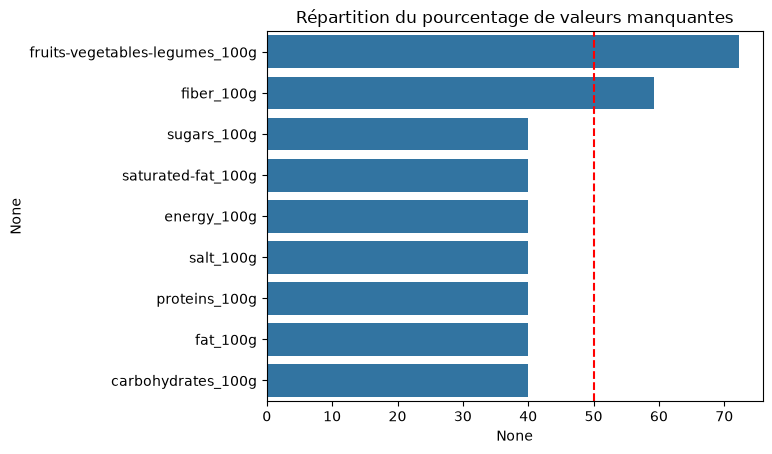

In [4]:
# affiche le graph du % des valeurs manquantes avec seuil 

percent_missing_9 = preprocess_9["percent_missing"]
filtered = percent_missing_9[percent_missing_9.values > 0]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h');
ax.set_title(f"Répartition du pourcentage de valeurs manquantes");

threshold = 50

ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}") 



In [5]:
##vérifie qu'après "drop_rows_all_missing" on a des Nan ou pas à imputer.
## résultat = 1 valeur manquante dans saturated-fat et dans sugars 

from preprocess import load_data, split_known_unknown, split_train_test, compute_missing_percentage, get_columns_to_drop, apply_column_drop, drop_rows_all_missing

df = load_data(sample_size=10000)
df_connu, df_inconnu = split_known_unknown(df, target_col="nutriscore_grade")
X_train, X_test, y_train, y_test = split_train_test(df_connu, mes_features)

percent_missing = compute_missing_percentage(X_train)
columns_to_drop = get_columns_to_drop(percent_missing, threshold=50) 

X_train_avant_imputation = apply_column_drop(X_train, columns_to_drop)
X_train_avant_imputation = drop_rows_all_missing(X_train_avant_imputation)

print(X_train_avant_imputation.isna().sum())

energy_100g           0
saturated-fat_100g    1
sugars_100g           1
salt_100g             0
proteins_100g         0
fat_100g              0
carbohydrates_100g    0
dtype: int64


d:\Code_data\DESU_ROCHET\test\preprocess.py:26: DtypeWarning: Columns (0: abbreviated_product_name, 1: packaging_text, 2: no_nutrition_data) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path, sep=sep, encoding=encoding, nrows=sample_size, quoting=csv.QUOTE_NONE)


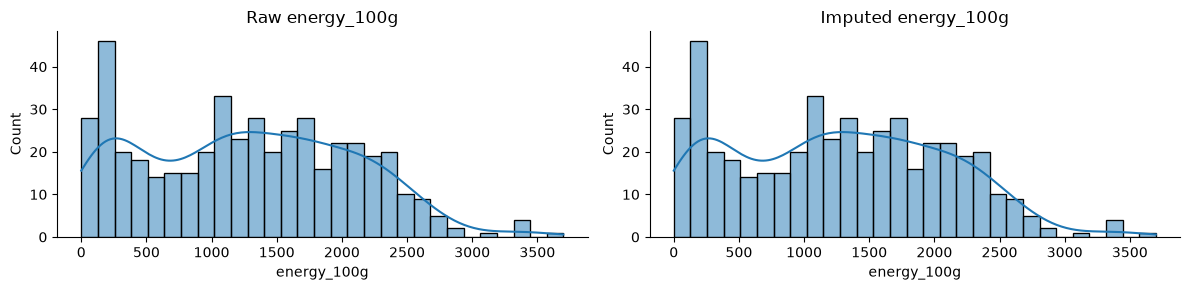

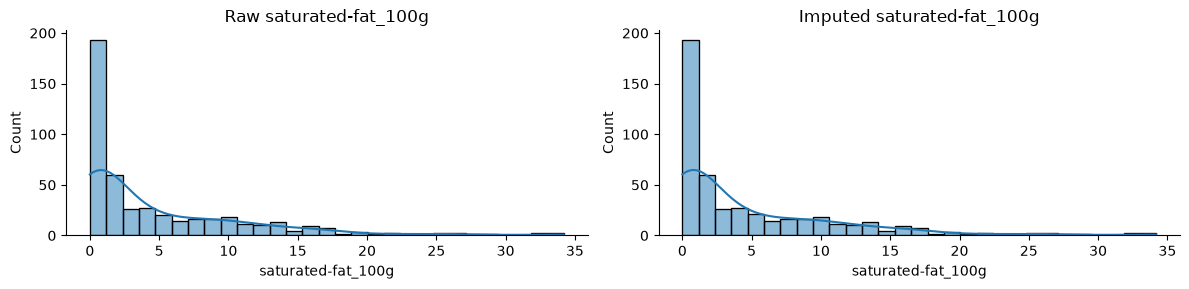

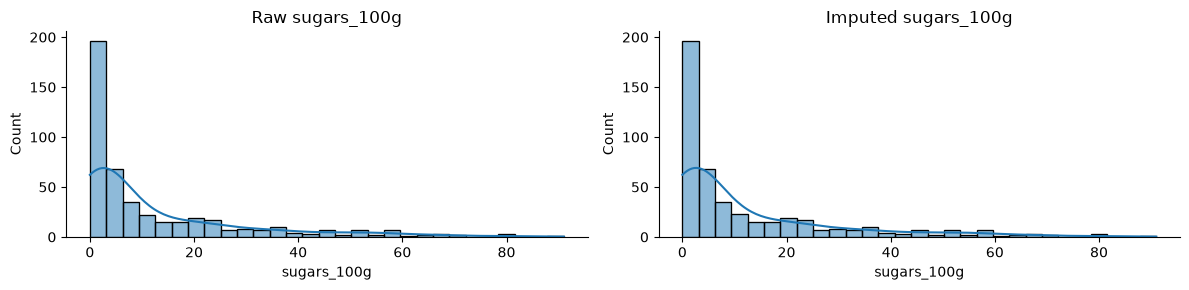

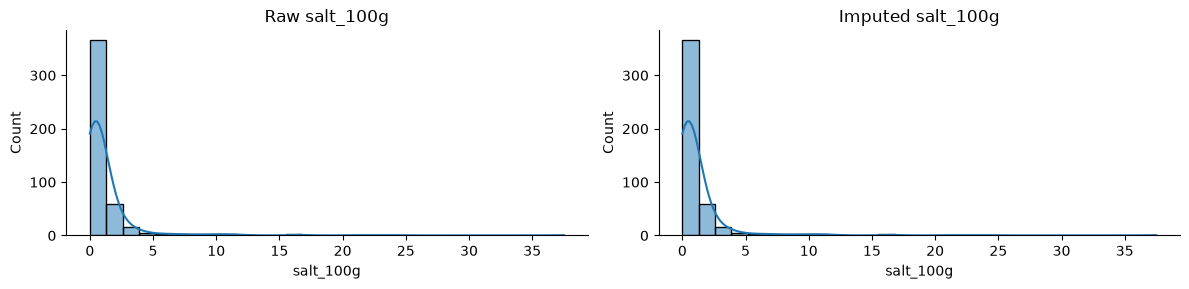

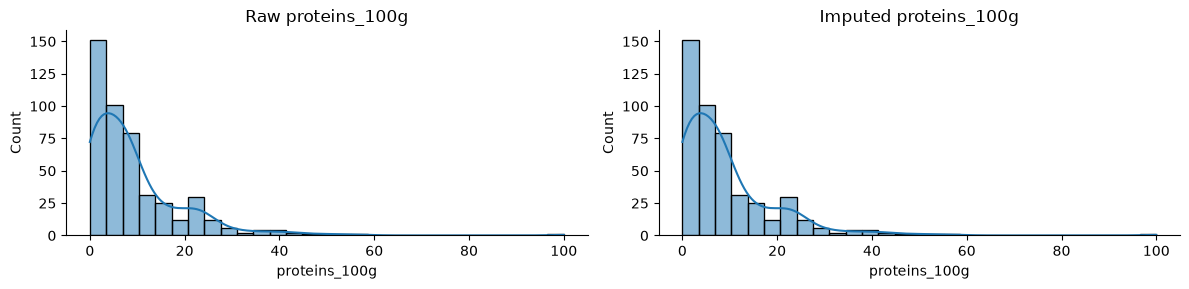

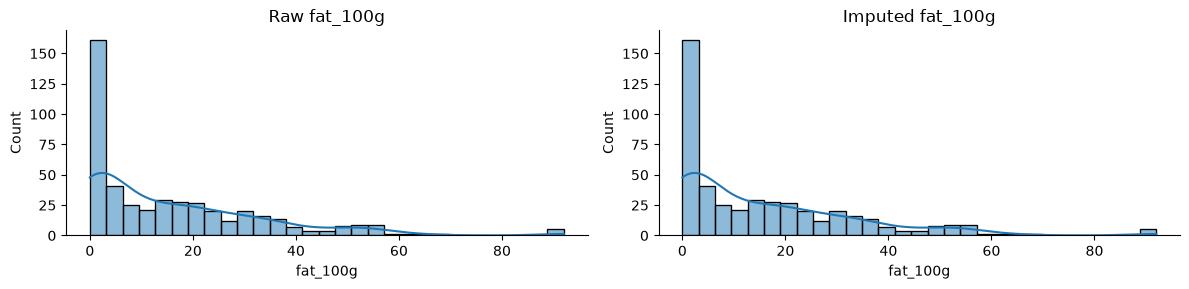

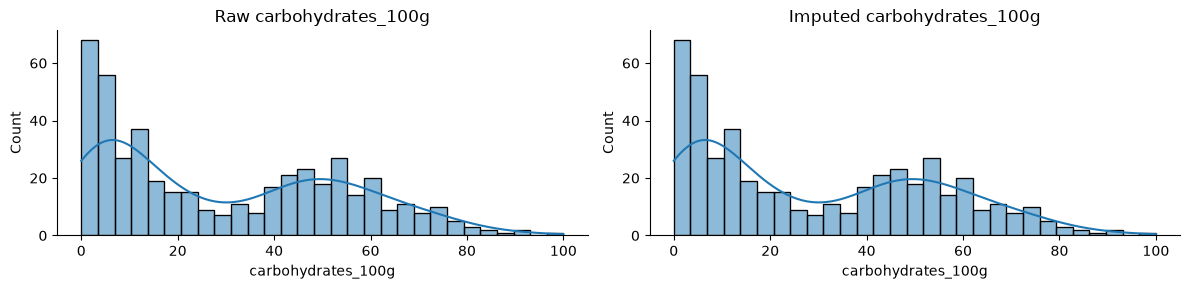

In [6]:
# Comparer avant/après imputation pour voir si les valeurs imputées sont cohérentes avec le reste de la colonne.

X_train_imputed = preprocess_9["X_train"]
features_restantes = list(X_train_imputed.columns)  # colonnes qui ont survécu au drop

def compare_dist(feature, raw_df, imputed_df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))

    # Bins communs calculés sur la plage combinée des deux distributions
    combined_min = min(raw_df[feature].min(), imputed_df[feature].min())
    combined_max = max(raw_df[feature].max(), imputed_df[feature].max())
    bins = np.linspace(combined_min, combined_max, 30)

    ax = axes[0]
    sns.histplot(raw_df.loc[:, feature], kde=True, ax=ax, bins=bins)
    ax.set_title(f"Raw {feature}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axes[1]
    sns.histplot(imputed_df.loc[:, feature], kde=True, ax=ax, bins=bins)
    ax.set_title(f"Imputed {feature}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

for feature in features_restantes:
    compare_dist(feature, X_train_avant_imputation, X_train_imputed)


Même pipeline mais sur TOUT le fichier (pas juste sample_size lignes), lu par morceaux (chunksize) pour ne pas tout charger en mémoire d'un coup (prend 8mn sur mon ordi(juliette))

In [2]:
from preprocess import preprocess_pipeline
from outliers import identify_impossible, apply_impossible_drop

from logreg import (
    plot_correlation_matrix,
    compute_vif,
    train_ordinal_logit,
    evaluate_ordinal_model,
    run_lasso_logit,
)

mes_features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
            'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g',
            'fat_100g', 'carbohydrates_100g']

preprocess_full = preprocess_pipeline(
    file_path=r"..\data\en.openfoodfacts.org.products.csv.gz",
    chunksize=100_000,
    missing_threshold=50,
    features=mes_features,
)

X_train, y_train = preprocess_full["X_train"], preprocess_full["y_train"]
X_test,  y_test  = preprocess_full["X_test"],  preprocess_full["y_test"]
X_inconnu        = preprocess_full["X_inconnu"]

print("Avant nettoyage :")
print("Train :", X_train.shape, "| Test :", X_test.shape, "| Inconnu :", X_inconnu.shape)
print(preprocess_full["X_train"].shape)
preprocess_full["X_train"].head()

# Nettoyage des valeurs impossibles
X_train, y_train = apply_impossible_drop(X_train, y_train)
X_test,  y_test  = apply_impossible_drop(X_test, y_test)
X_inconnu        = apply_impossible_drop(X_inconnu)

print("\nAprès nettoyage :")
print("Train :", X_train.shape, "| Test :", X_test.shape, "| Inconnu :", X_inconnu.shape)

Avant nettoyage :
Train : (758485, 7) | Test : (190228, 7) | Inconnu : (1320742, 7)
(758485, 7)

Après nettoyage :
Train : (755680, 7) | Test : (189498, 7) | Inconnu : (1178921, 7)


In [4]:
print("Lignes vides supprimées :", preprocess_full["lignes_vides_supprimees"])

import pandas as pd

# Affichage propre sous forme de tableau plutôt qu'un dict imprimé brut
manquants = preprocess_full["valeurs_manquantes_avant_imputation"]
df_manquants = pd.DataFrame(manquants)
print(df_manquants)

Lignes vides supprimées : {'train': 342843, 'test': 85105, 'inconnu': 1838150}
                    train  test  inconnu
energy_100g           454   125    31282
saturated-fat_100g   3483   821   135470
sugars_100g          1846   477   121271
salt_100g             208    47   315806
proteins_100g         529   141    52238
fat_100g              530   138    55933
carbohydrates_100g   1283   328    54477


In [5]:
##c'est bizarre qu'il y ai BCP plus de outliers enlevés dans Test qu'en TRAIN 
#d'où vient le problème ? 

X_train_brut = preprocess_full["X_train"]
X_test_brut  = preprocess_full["X_test"]

print("Shape train brut :", X_train_brut.shape)
print("Shape test brut  :", X_test_brut.shape)

_, comptes_train = identify_impossible(X_train_brut)
_, comptes_test  = identify_impossible(X_test_brut)

print("\nComptes train :", comptes_train)
print("Comptes test  :", comptes_test)


Shape train brut : (758485, 7)
Shape test brut  : (190228, 7)

Comptes train : {'energy_100g': 391, 'saturated-fat_100g': 70, 'sugars_100g': 1985, 'salt_100g': 319, 'proteins_100g': 607, 'fat_100g': 177, 'carbohydrates_100g': 325}
Comptes test  : {'energy_100g': 85, 'saturated-fat_100g': 22, 'sugars_100g': 504, 'salt_100g': 93, 'proteins_100g': 161, 'fat_100g': 39, 'carbohydrates_100g': 76}


In [6]:
#on voit que  sugars a 1985  et 85609 dans test, et protéines 85266 valeurs supprimées, ce qui doit etre la cause du pb

##le problème vient du fait qu'on ai fait une imputation AVANT de faire le nettoyage des valeurs impossibles
#donc on a une moyenne qui inclut les grandes valeurs impossible ce qui fausse les résultats

print("sugars_100g - X_train :")
print(X_train_brut["sugars_100g"].describe())

print("\nsugars_100g - X_test :")
print(X_test_brut["sugars_100g"].describe())

print("\nproteins_100g - X_train :")
print(X_train_brut["proteins_100g"].describe())

print("\nproteins_100g - X_test :")
print(X_test_brut["proteins_100g"].describe())

sugars_100g - X_train :
count    7.584850e+05
mean     1.322860e+04
std      1.148224e+07
min      0.000000e+00
25%      6.000000e-01
50%      3.300000e+00
75%      1.400000e+01
max      1.000000e+10
Name: sugars_100g, dtype: float64

sugars_100g - X_test :
count    190228.000000
mean         44.874266
std         661.273006
min           0.000000
25%           0.600000
50%           3.300000
75%          14.000000
max       13228.603518
Name: sugars_100g, dtype: float64

proteins_100g - X_train :
count    7.584850e+05
mean     4.880905e+03
std      3.121542e+06
min     -5.437500e-03
25%      2.200000e+00
50%      6.500000e+00
75%      1.270000e+01
max      2.522222e+09
Name: proteins_100g, dtype: float64

proteins_100g - X_test :
count    190228.000000
mean         12.388817
std         132.991628
min          -4.761905
25%           2.100000
50%           6.500000
75%          12.700000
max        4880.904673
Name: proteins_100g, dtype: float64


In [2]:
from preprocess import preprocess_pipeline
from outliers import identify_impossible, apply_impossible_drop

from logreg import (
    plot_correlation_matrix,
    compute_vif,
    train_ordinal_logit,
    evaluate_ordinal_model,
    run_lasso_logit,
)

mes_features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
            'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g',
            'fat_100g', 'carbohydrates_100g']

preprocess_full = preprocess_pipeline(
    file_path=r"..\data\en.openfoodfacts.org.products.csv.gz",
    chunksize=100_000,
    missing_threshold=50,
    features=mes_features,
)

X_train, y_train = preprocess_full["X_train"], preprocess_full["y_train"]
X_test,  y_test  = preprocess_full["X_test"],  preprocess_full["y_test"]
X_inconnu        = preprocess_full["X_inconnu"]

print("Avant nettoyage :")
print("Train :", X_train.shape, "| Test :", X_test.shape, "| Inconnu :", X_inconnu.shape)
print(preprocess_full["X_train"].shape)
preprocess_full["X_train"].head()

# Nettoyage des valeurs impossibles
X_train, y_train = apply_impossible_drop(X_train, y_train)
X_test,  y_test  = apply_impossible_drop(X_test, y_test)
X_inconnu        = apply_impossible_drop(X_inconnu)

print("\nAprès nettoyage :")
print("Train :", X_train.shape, "| Test :", X_test.shape, "| Inconnu :", X_inconnu.shape)

Avant nettoyage :
Train : (757541, 7) | Test : (189986, 7) | Inconnu : (1319237, 7)
(757541, 7)

Après nettoyage :
Train : (757541, 7) | Test : (189986, 7) | Inconnu : (1319237, 7)


In [3]:
print("Lignes vides supprimées :", preprocess_full["lignes_vides_supprimees"])

import pandas as pd

# Affichage propre sous forme de tableau plutôt qu'un dict imprimé brut
manquants = preprocess_full["valeurs_manquantes_avant_imputation"]
df_manquants = pd.DataFrame(manquants)
print(df_manquants)

# Vérification que la moyenne d'imputation de sugars_100g n'est plus polluée
print("\nMoyenne imputation sugars_100g :", preprocess_full["valeurs_imputation"]["sugars_100g"])

Lignes vides supprimées : {'train': 342843, 'test': 85105, 'inconnu': 1838150}
                    train  test  inconnu
energy_100g           453   125    31247
saturated-fat_100g   3471   819   134988
sugars_100g          1836   477   120843
salt_100g             208    47   315306
proteins_100g         528   141    52044
fat_100g              529   138    55761
carbohydrates_100g   1245   318    54302

Moyenne imputation sugars_100g : 11.726521722969514


In [38]:
# Nombre de lignes "connu" = train + test (après split, donc après pipeline)
nb_connu = len(preprocess_full["y_train"]) + len(preprocess_full["y_test"])
print("Nombre de lignes connu (train+test) :", nb_connu)

# Nombre de lignes "inconnu" (après nettoyage dans la pipeline)
nb_inconnu = len(preprocess_full["X_inconnu"])
print("Nombre de lignes inconnu :", nb_inconnu)

# Total
print("Total :", nb_connu + nb_inconnu)

# Répartition connu/inconnu en %
total = nb_connu + nb_inconnu
print(f"Connu : {nb_connu} ({nb_connu/total*100:.1f}%)")
print(f"Inconnu : {nb_inconnu} ({nb_inconnu/total*100:.1f}%)")

Nombre de lignes connu (train+test) : 1033818
Nombre de lignes inconnu : 1320742
Total : 2354560
Connu : 1033818 (43.9%)
Inconnu : 1320742 (56.1%)


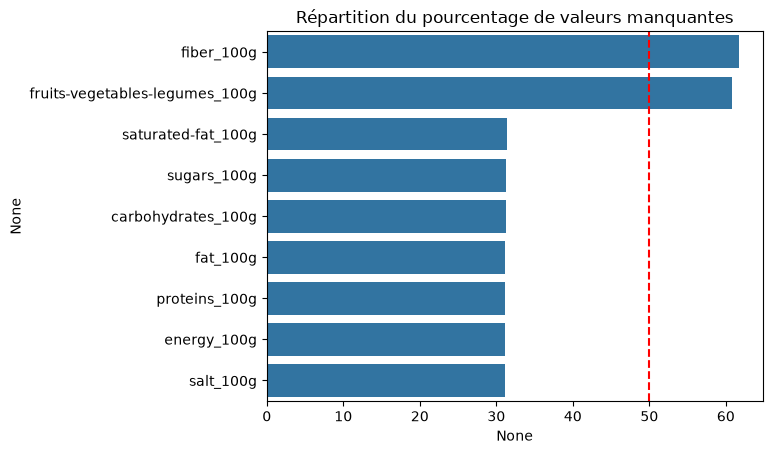

In [7]:
percent_missing_full = preprocess_full["percent_missing"]
filtered = percent_missing_full[percent_missing_full.values > 0]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h');
ax.set_title(f"Répartition du pourcentage de valeurs manquantes");

threshold = 50

ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")

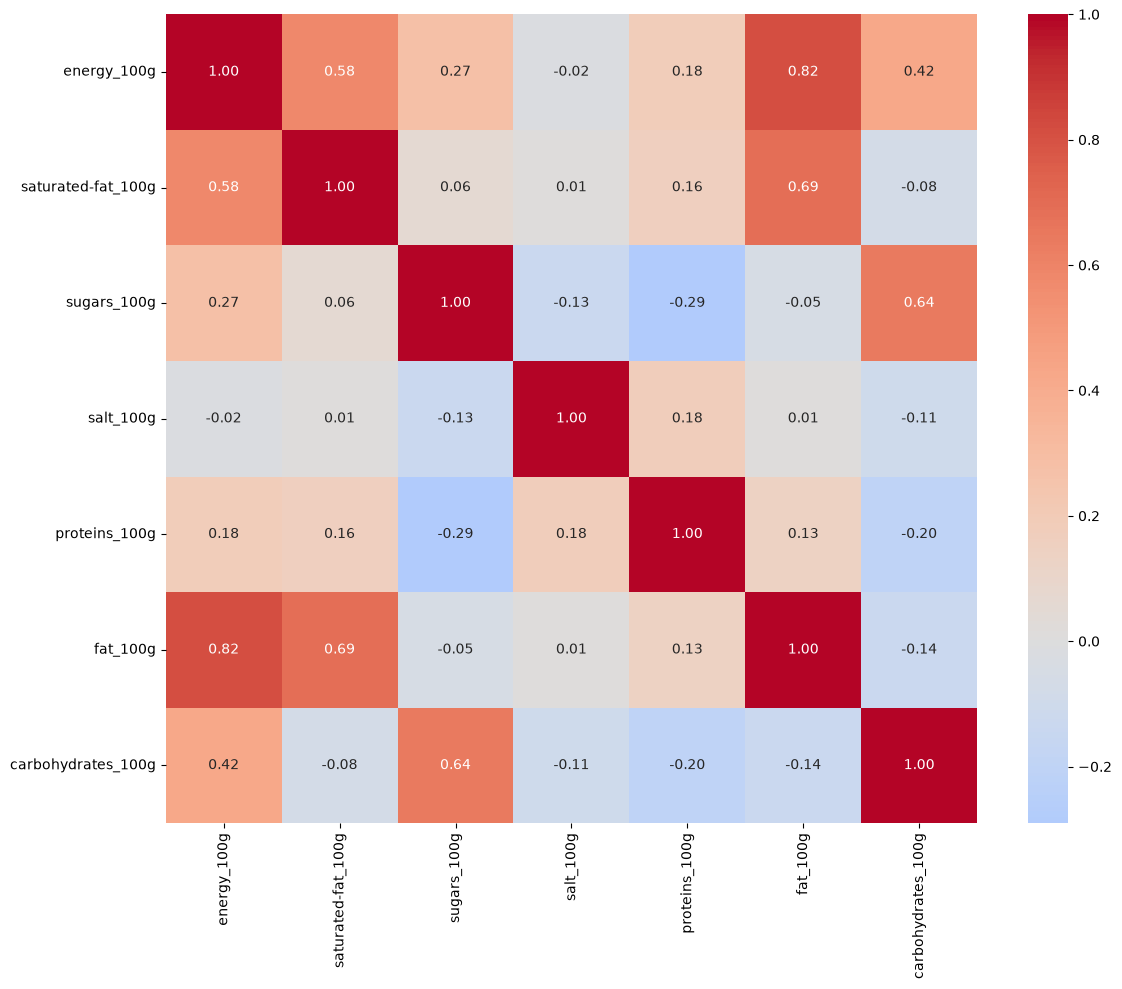

             variable        VIF
0         energy_100g  92.102392
1  saturated-fat_100g   1.991929
2         sugars_100g   1.864908
3           salt_100g   1.041214
4       proteins_100g   4.308854
5            fat_100g  71.740447
6  carbohydrates_100g  32.720897

Variables gardées (VIF < 5.0) : ['saturated-fat_100g', 'sugars_100g', 'salt_100g', 'proteins_100g']


In [13]:
df_train_full = X_train.copy()
df_train_full["nutriscore_grade"] = y_train

corr = plot_correlation_matrix(
    df_train_full,
    target_col="nutriscore_grade"
)

vif_data, vif_ok = compute_vif(
    df_train_full,
    target_col="nutriscore_grade",
    threshold=5.0
)

Modèle régression logistique ordinal

In [10]:
from logreg import train_ordinal_logit, evaluate_ordinal_model

X_train = preprocess_full["X_train"]
X_test  = preprocess_full["X_test"]
y_train = preprocess_full["y_train"]
y_test  = preprocess_full["y_test"]

result, scaler = train_ordinal_logit(X_train, y_train)
pred, probas = evaluate_ordinal_model(result, scaler, X_test, y_test)

Optimization terminated successfully.
         Current function value: 0.971333
         Iterations: 46
         Function evaluations: 47
         Gradient evaluations: 47
                             OrderedModel Results                             
Dep. Variable:       nutriscore_grade   Log-Likelihood:            -7.3582e+05
Model:                   OrderedModel   AIC:                         1.472e+06
Method:            Maximum Likelihood   BIC:                         1.472e+06
Date:                Wed, 26 Aug 2026                                         
Time:                        10:55:19                                         
No. Observations:              757541                                         
Df Residuals:                  757530                                         
Df Model:                           7                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------

Accuracy : 0.6241828345246492


problème = b n'est jamais prédis ! 
ça suggère que les produits notés "b" ressemblent statistiquement soit beaucoup à "a" soit beaucoup à "c" sur ces 7 variables nutritionnelles

In [ ]:
#comparaison avec le random forest 

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

modeles = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced"),
}

resultats = {}
modeles_entraines = {}

for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    acc = accuracy_score(y_test, modele.predict(X_test))
    resultats[nom] = acc
    modeles_entraines[nom] = modele
    print(f"{nom}: accuracy = {acc:.3f}")


RandomForest: accuracy = 0.878


NameError: name 'clf' is not defined

In [16]:
clf = modeles_entraines["RandomForest"]
y_pred_rf = clf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           a       0.85      0.85      0.85     27414
           b       0.76      0.78      0.77     22154
           c       0.84      0.85      0.85     42131
           d       0.91      0.91      0.91     49042
           e       0.94      0.94      0.94     49245

    accuracy                           0.88    189986
   macro avg       0.86      0.86      0.86    189986
weighted avg       0.88      0.88      0.88    189986



Random Forest identifie très bien la classe "b" (recall 0.78, f1 0.77) — comparable aux autres classes — alors que ton modèle ordinal logit n'en identifiait aucune (recall = 0 sur toute la colonne "b" prédite).

Random Forest meilleur modele ! 

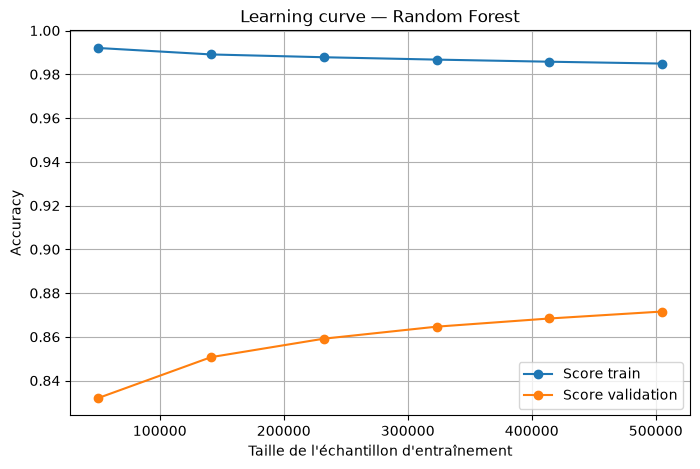

In [17]:
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced")

train_sizes, train_scores, val_scores = learning_curve(
    rf, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 6),  # 10%, 28%, 46%, 64%, 82%, 100% du train
    cv=3,                # 3 folds suffisent, 5 double le temps de calcul
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", label="Score train")
plt.plot(train_sizes, val_mean, "o-", label="Score validation")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Accuracy")
plt.title("Learning curve — Random Forest")
plt.legend()
plt.grid(True)
plt.show()

On compare différents modèle, on prend celui à la meilleure accuracy et on prédit le nutriscore sur les lignes avec un nutriscore inconnu

In [11]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

modeles = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced"),
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

resultats = {}
modeles_entraines = {}

for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    acc = accuracy_score(y_test, modele.predict(X_test))
    resultats[nom] = acc
    modeles_entraines[nom] = modele
    print(f"{nom}: accuracy = {acc:.3f}")

# Sélection automatique du meilleur modèle (celui avec la meilleure accuracy sur X_test)
meilleur_nom = max(resultats, key=resultats.get)
meilleur_modele = modeles_entraines[meilleur_nom]
print(f"\nMeilleur modèle : {meilleur_nom} (accuracy = {resultats[meilleur_nom]:.3f})")

# Application du meilleur modèle sur les lignes inconnues
predictions_inconnu = meilleur_modele.predict(X_inconnu)

# Optionnel : recoller les prédictions au df_inconnu original pour les consulter
import pandas as pd
resultat_final = X_inconnu.copy()
resultat_final["nutriscore_predit"] = predictions_inconnu
resultat_final.head()

RandomForest: accuracy = 0.653


d:\Code_data\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression: accuracy = 0.283
GradientBoosting: accuracy = 0.587

Meilleur modèle : RandomForest (accuracy = 0.653)


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g,nutriscore_predit
604,9.00,3.600000,4.900000,1.795091,17.500000,10.20000,22.500000,d
605,856.00,3.400000,1.900000,0.700000,5.900000,12.10000,18.100000,c
606,2770.00,16.129032,3.225806,0.524194,19.677419,54.83871,19.354839,d
712,2221.96,19.300000,37.720000,0.270000,5.680000,30.28000,59.120000,e
744,1982.00,11.000000,65.000000,0.120000,5.700000,19.00000,69.000000,e


In [14]:
print("Nombre de lignes prédites :", resultat_final.shape[0])
resultat_final.sample(20, random_state=42)


Nombre de lignes prédites : 1320742


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g,nutriscore_predit
2627853,3389.200000,13.600000,0.000000,0.000000,0.000000,91.600000,0.000000,b
1618818,1493.100000,0.200000,3.000000,1.795091,12.000000,1.300000,73.000000,d
2451693,1301.000000,5.510514,13228.603518,1.795091,0.400000,15.020009,75.000000,e
630048,417.000000,0.800000,0.000000,2.300000,16.000000,3.000000,2.000000,d
174941,220.000000,0.000000,3.529412,1.795091,2.352941,0.000000,10.588235,c
731339,2325.000000,5.357143,0.000000,0.223214,3.571429,28.571429,64.285714,d
2455235,92.384615,0.000000,2.615385,0.065385,0.923077,0.000000,4.076923,a
1415438,1429.700000,2.800000,0.500000,1.000000,8.700000,34.000000,1.400000,c
1297728,536.600000,6.200000,0.800000,0.570000,6.000000,10.000000,3.800000,c
2940988,211.100000,0.100000,3.700000,0.100000,8.500000,0.100000,3.700000,a


In [ ]:
from sklearn.metrics import accuracy_score

pred_train = probas_train.idxmax(axis=1)  # ou refaire predict sur X_train_scaled
acc_train = accuracy_score(y_train, pred_train)
acc_test = accuracy_score(y_test, pred)  # pred vient déjà de evaluate_ordinal_model

print(f"Accuracy train : {acc_train:.3f}")
print(f"Accuracy test  : {acc_test:.3f}")